In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#Load the dataset
df_airport = pd.read_csv("complaints-by-airport.csv")
df_category = pd.read_csv("complaints-by-category.csv")
df_subcategory = pd.read_csv("complaints-by-subcategory.csv")
df_airport_codes = pd.read_csv("iata-icao.csv")

In [17]:
#Merge airpot data with iata
df_airport_merged = df_airport.merge(df_airport_codes,left_on="airport",right_on="iata",how="left")

In [29]:
#Merge category and subcategory
df_cat_subcat = df_category.merge(df_subcategory,on=["airport", "category", "year_month"],how="left")

In [31]:
#Merge above data with iata data
df_cat_subcat_merged = df_cat_subcat.merge(df_airport_codes,left_on="airport",right_on="iata",how="left")

Visualizations

In [40]:
top_airports = df_airport_merged.groupby("airport_x")["count"].sum().nlargest(10).index
heatmap_data = df_airport_merged[df_airport_merged["airport_x"].isin(top_airports)]
heatmap_pivot = heatmap_data.pivot_table(index="airport_x", columns="year_month", values="count", aggfunc="sum").fillna(0)

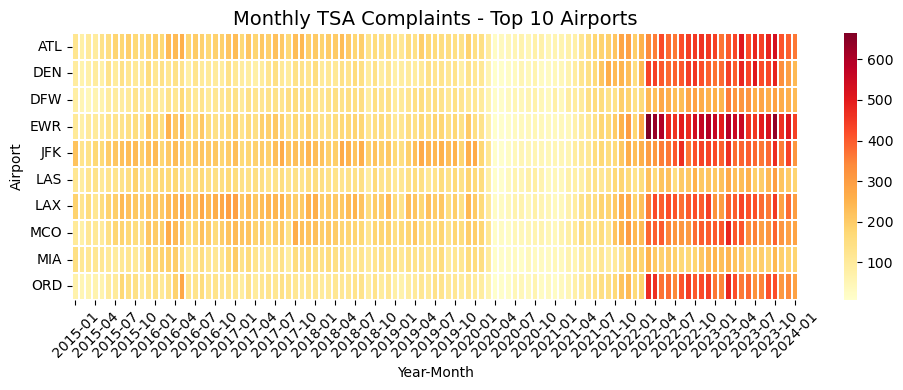

In [49]:
plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_pivot, cmap="YlOrRd", linewidths=0.1)
plt.title("Monthly TSA Complaints - Top 10 Airports", fontsize=14)
plt.xlabel("Year-Month")
plt.ylabel("Airport")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

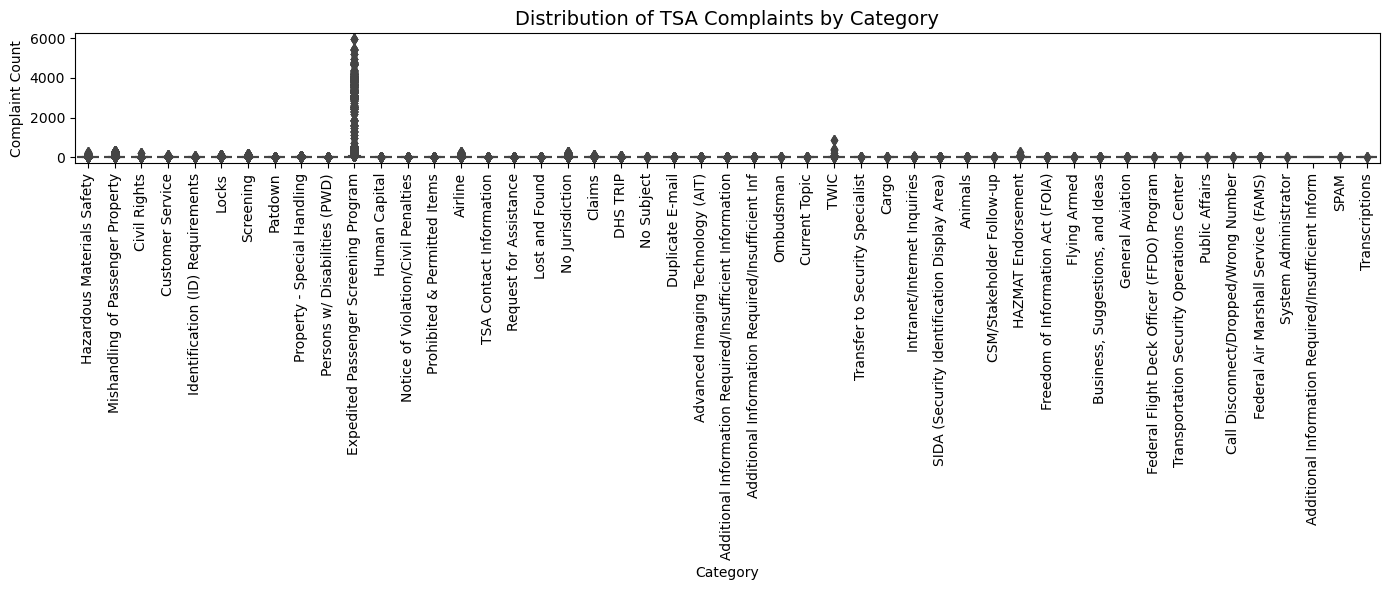

In [53]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_cat_subcat_merged, x="category", y="count_x")
plt.xticks(rotation=90)
plt.title("Distribution of TSA Complaints by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Complaint Count")
plt.tight_layout()
plt.show()

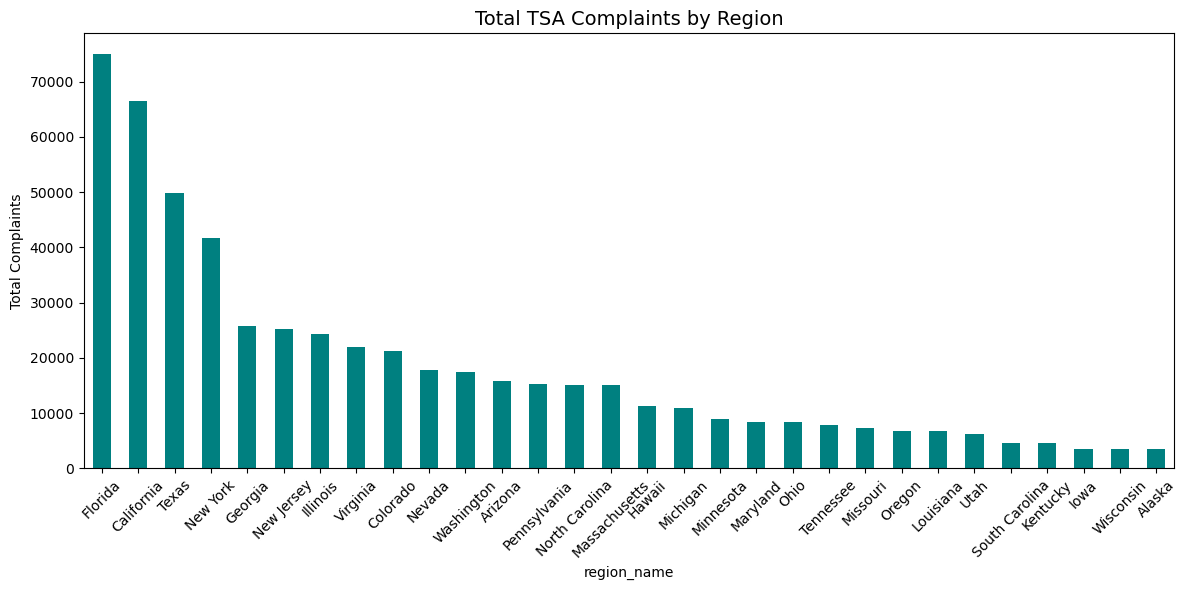

In [73]:
region_complaints = df_airport_merged.groupby("region_name")["count"].sum().sort_values(ascending=False).head(30)

plt.figure(figsize=(12, 6))
region_complaints.plot(kind="bar", color="teal")
plt.title("Total TSA Complaints by Region", fontsize=14)
plt.ylabel("Total Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

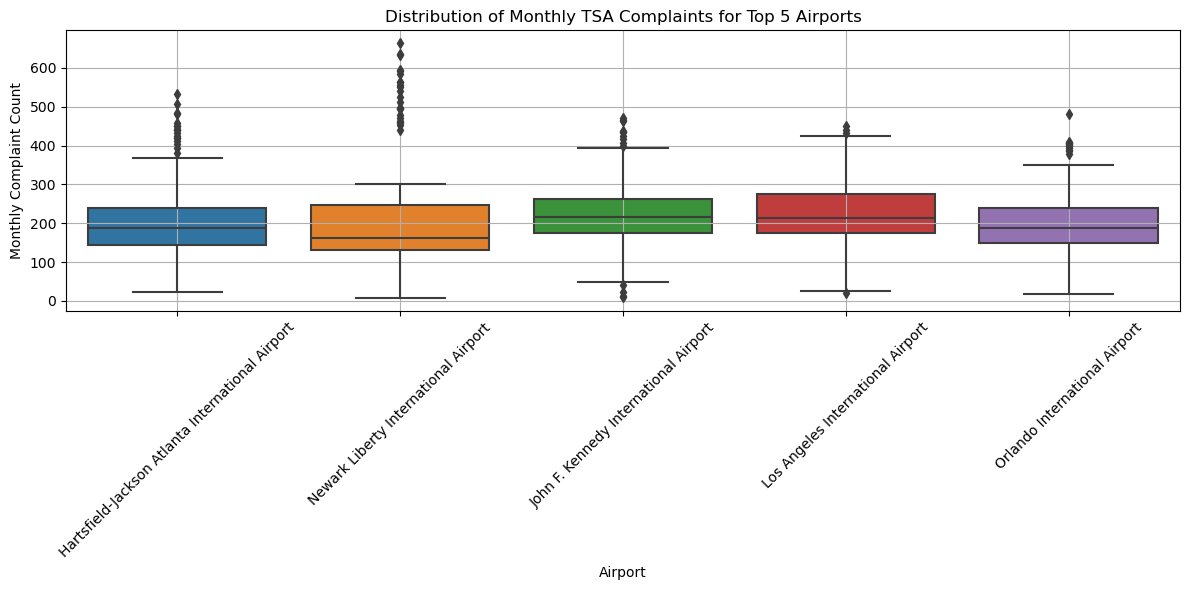

In [85]:
df_airport_merged['year_month'] = pd.to_datetime(df_airport_merged['year_month'])
df_airport_merged.rename(columns={'airport_y': 'airport_name', 'count': 'complaint_count'}, inplace=True)
top5_airports = (df_airport_merged.groupby('airport_name')['complaint_count'].sum().nlargest(5).index)

# Filter to top 5
df_top5 = df_airport_merged[df_airport_merged['airport_name'].isin(top5_airports)]

# Create the box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top5, x='airport_name', y='complaint_count')
plt.title("Distribution of Monthly TSA Complaints for Top 5 Airports")
plt.xlabel("Airport")
plt.ylabel("Monthly Complaint Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

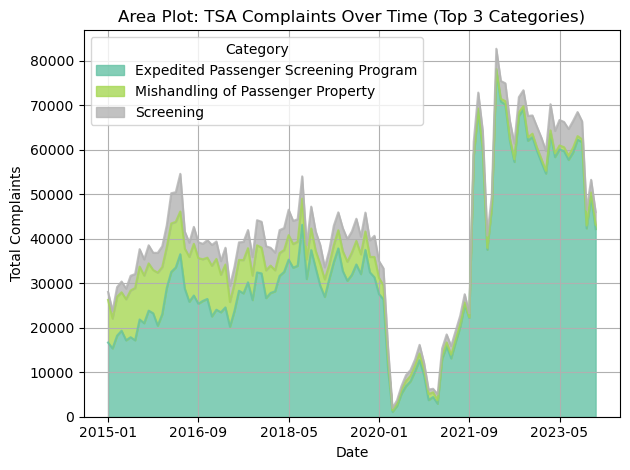

In [95]:
# Group by category and date
category_monthly = df_cat_subcat_merged.groupby(['category', 'year_month'])['count_x'].sum().reset_index()

# Find top 3 complaint categories overall
top3_categories = (category_monthly.groupby('category')['count_x'].sum().nlargest(3).index)

# Filter for top 3 categories only
df_top3_area = category_monthly[category_monthly['category'].isin(top3_categories)]

# Pivot data for plotting
pivot_area = df_top3_area.pivot(index='year_month', columns='category', values='count_x').fillna(0)

# Plot area chart
plt.figure(figsize=(12, 6))
pivot_area.plot.area(stacked=True, colormap='Set2', alpha=0.8)
plt.title('Area Plot: TSA Complaints Over Time (Top 3 Categories)')
plt.xlabel('Date')
plt.ylabel('Total Complaints')
plt.legend(title='Category', loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

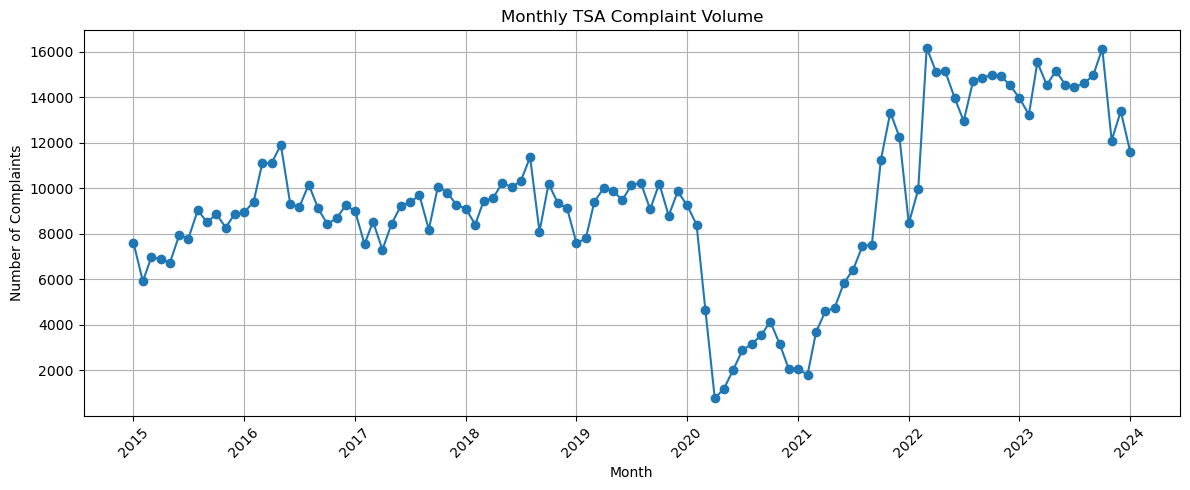

In [101]:
monthly_trend = df_airport_merged.groupby('year_month')['complaint_count'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_trend['year_month'], monthly_trend['complaint_count'], marker='o', linestyle='-')
plt.title('Monthly TSA Complaint Volume')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


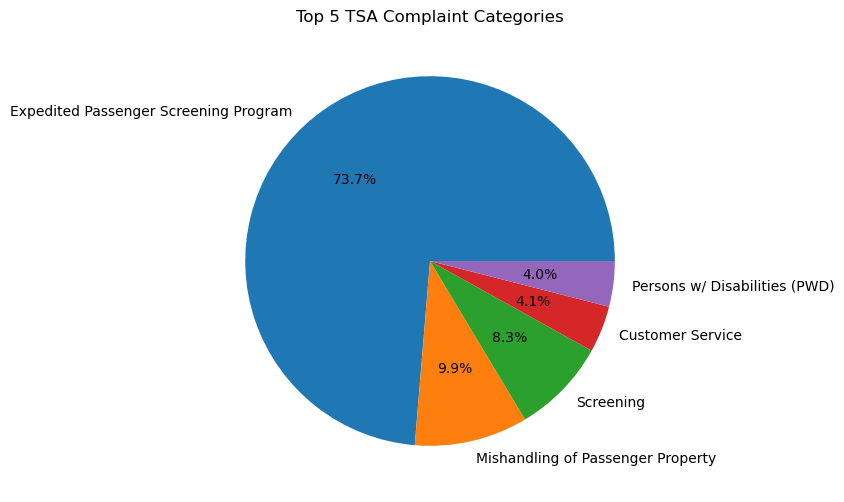

In [107]:
cat_totals = df_cat_subcat_merged.groupby("category")["count_x"].sum().nlargest(5)

cat_totals.plot.pie(autopct='%1.1f%%', figsize=(6,6), title="Top 5 TSA Complaint Categories")
plt.ylabel("")
plt.show()